# 6-3. ARIMA의 파생 모델

In [ ]:
# 1 데이터 연결하기
# 먼저 데이터가 저장된 폴더를 연결합시다.
# !mkdir -p aiffel/time_series_basic
# #!ln -s data/* aiffel/time_series_basic
# !cp data/Daily_Demand_Forecasting_Orders.csv aiffel/time_series_basic/

In [ ]:
# 2 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
!pip install pmdarima # Install pmdarima if not already installed
import pmdarima as pm

In [ ]:
# 3 데이터 불러오기
df = pd.read_csv('Daily_Demand_Forecasting_Orders.csv', delimiter=';')

In [ ]:
# 4 데이터 확인
df.columns

Index(['Week of the month (first week, second, third, fourth or fifth week',
       'Day of the week (Monday to Friday)', 'Non-urgent order',
       'Urgent order', 'Order type A', 'Order type B', 'Order type C',
       'Fiscal sector orders', 'Orders from the traffic controller sector',
       'Banking orders (1)', 'Banking orders (2)', 'Banking orders (3)',
       'Target (Total orders)'],
      dtype='object')

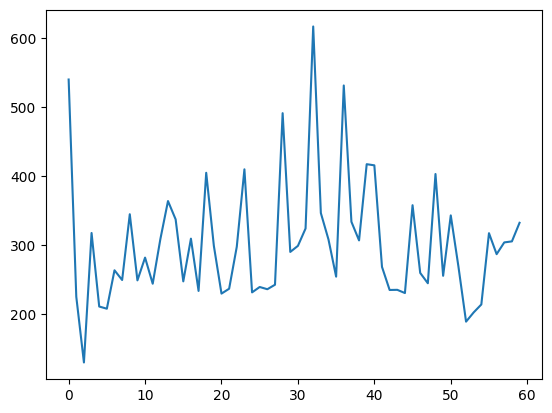

In [ ]:
# 4 데이터 확인 및 시각화
# dataframe에 있는 column들을 불러옵니다. (데이터 내부에 feature를 가져옵니다.)
# dataframe에 있는 Target (Total orders)을 시각화합니다.

data = df['Target (Total orders)']
plt.plot(data)
plt.show()

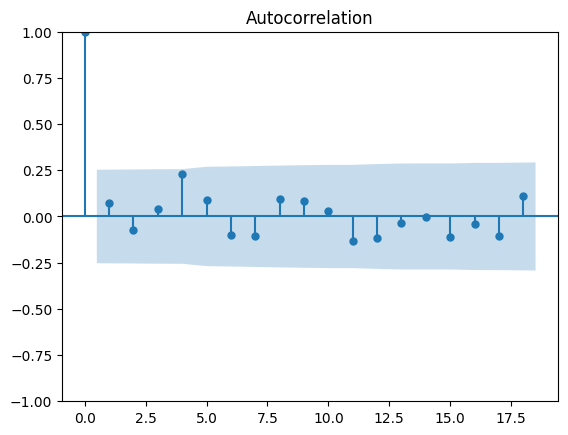

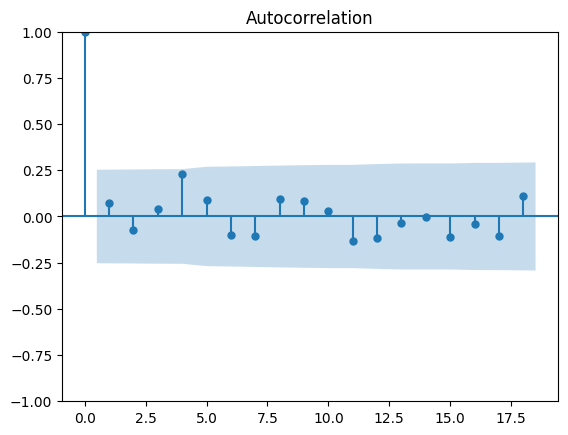

In [ ]:
# 5 ACF를 통한 데이터 확인 및 시각화
plot_acf(data)

In [ ]:
# 6 ARIMA 적용
model1 = ARIMA(data, order=(1,0,0))
model2 = ARIMA(data, order=(0,0,1))
model3 = ARIMA(data, order=(1,0,1))

res1 = model1.fit()
res2 = model2.fit()
res3 = model3.fit()

In [ ]:
# 7 ARIMA 결과 확인
# fittedvalues : 주어진 값 x를 회귀 방정식에 대입해서 결과를 알려줍니다.
# y^                   : 모델을 거쳐서 나온 예측된 결과로 부를 수 있습니다.
# y^_i = b_0 + b_1 x_i : 수식에서 y는 적합된 값(fitted value)입니다.
# e_t​ =y_t − y^_t      : 수식에서 e는 잔차 입니다. 잔차는 관측치와 해당 적합된 값 사이의 차이와 같습니다.
# 시각화를 통해 fitted value를 데이터셋과 비교해 봅니다.

In [ ]:
print(res1.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Target (Total orders)   No. Observations:                   60
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -354.181
Date:                   Fri, 20 Feb 2026   AIC                            714.362
Time:                           02:22:01   BIC                            720.645
Sample:                                0   HQIC                           716.819
                                    - 60                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        301.0429     17.323     17.378      0.000     267.090     334.995
ar.L1          0.0804      0.187      0.430      0.667      -0.286       0.447
sigma2      7848.5794   1363

In [ ]:
print(res2.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Target (Total orders)   No. Observations:                   60
Model:                    ARIMA(0, 0, 1)   Log Likelihood                -354.143
Date:                   Fri, 20 Feb 2026   AIC                            714.286
Time:                           02:22:02   BIC                            720.569
Sample:                                0   HQIC                           716.743
                                    - 60                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        301.3222     17.628     17.094      0.000     266.773     335.872
ma.L1          0.0982      0.179      0.548      0.583      -0.253       0.449
sigma2      7837.9594   1382

In [ ]:
print(res3.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Target (Total orders)   No. Observations:                   60
Model:                    ARIMA(1, 0, 1)   Log Likelihood                -354.075
Date:                   Fri, 20 Feb 2026   AIC                            716.150
Time:                           02:22:02   BIC                            724.528
Sample:                                0   HQIC                           719.427
                                    - 60                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        301.2369     17.534     17.180      0.000     266.871     335.603
ar.L1         -0.2589      1.442     -0.180      0.857      -3.085       2.567
ma.L1          0.3581      1

In [ ]:
predictions = res2.fittedvalues

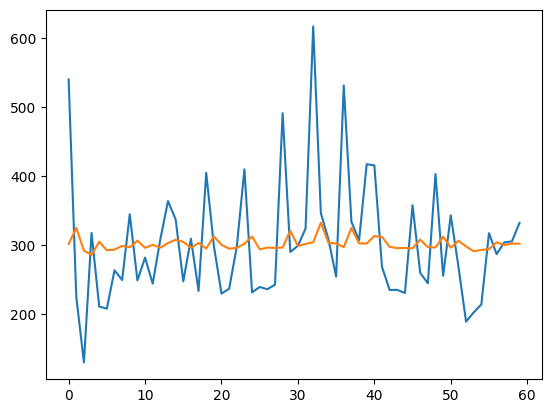

In [ ]:
plt.figure()
plt.plot(data)
plt.plot(predictions)
plt.show()

In [ ]:
# 8 Auto ARIMA 적용
# Auto ARIMA를 적용하여 나오는 결과와 summary를 통해 나온 결과를 비교 분석해봅시다.
model = pm.AutoARIMA(seasonal=False, stepwise=True, suppress_warnings=True, trace=True)

In [ ]:
res = model.fit(data)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.45 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=862.092, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=747.489, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=818.332, Time=0.15 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=741.019, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=735.047, Time=0.51 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=inf, Time=0.31 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=724.987, Time=0.61 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=723.726, Time=1.26 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=722.186, Time=0.30 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.71 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=791.913, Time=0.43 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=716.399, Time=0.37 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=714.286, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=712.710, Time=0.0

In [ ]:
# 결과 확인
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   60
Model:                        SARIMAX   Log Likelihood                -354.355
Date:                Fri, 20 Feb 2026   AIC                            712.710
Time:                        02:22:08   BIC                            716.898
Sample:                             0   HQIC                           714.348
                                 - 60                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    300.8733     15.236     19.747      0.000     271.011     330.736
sigma2      7894.7169   1313.366      6.011      0.000    5320.567    1.05e+04
Ljung-Box (L1) (Q):                   0.33   Jarque-